# Autoencoder Notebook (64x16x64)

This notebook trains a 64x16x64 autoencoder on the sklearn digits dataset using the `NeuralNetwork` class in `nn/nn.py`.

Steps:
1. Load Data
2. Instantiate autoencoder
3. Train autoencoder
4. Plot loss curves
5. Compute mean squared error on validation set

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from nn.nn import NeuralNetwork

%matplotlib inline

In [22]:
digits = load_digits()
# scale pixel intensities to [0, 1]
X = digits.data.astype(float) / 16.0
X_train, X_val = train_test_split(X, test_size=0.2, random_state=42)

## Hyperparameter Choices

- **Learning rate (0.01)**: This learning rate balances convergence speed and stability. Too high would cause divergence and too low would be slow.
- **Batch size (32)**: A standard batch size that provides good gradient estimates without excessive memory usage.
- **Epochs (100)**: I tried 50 and loss was still decreasing. 100 it was starting to converge more. Needed 150 for sufficient convergence on the digits dataset without excessive training time.
- **Loss function (MSE)**: Mean squared error is standard for reconstruction tasks since it directly measures pixel-wise differences.
- **Architecture (64→16→64)**: The bottleneck at 16 forces meaningful compression the symmetric decoder mirrors the encoder for reconstruction.

In [23]:
# Define and instantiate the 64 -> 16 -> 64 autoencoder
nn_arch = [
    {'input_dim': 64, 'output_dim': 16, 'activation': 'relu'},
    {'input_dim': 16, 'output_dim': 64, 'activation': 'sigmoid'}
]
model = NeuralNetwork(nn_arch, lr=0.01, seed=42, batch_size=32, epochs=150, loss_function='mean_squared_error')

In [24]:
# Train the autoencoder (targets are the inputs)
train_losses, val_losses = model.fit(X_train, X_train, X_val, X_val)

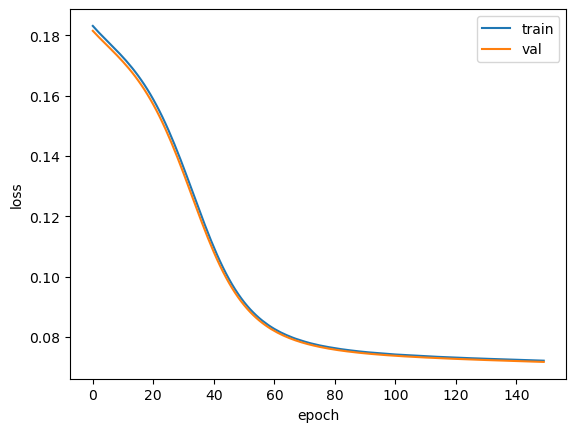

In [25]:
# Plot training and validation loss
import matplotlib.pyplot as plt
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [26]:
# Compute mean squared error on validation set
y_hat = model.predict(X_val)
mse = np.mean((X_val - y_hat) ** 2)
print('Validation MSE:', mse)

Validation MSE: 0.07176459715232873
